In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import os, warnings

warnings.filterwarnings('ignore')

# ── Configuration graphique globale ──────────────────────────────────────────
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
sns.set_palette('husl')

COLOR_PRIMARY = '#2C7BB6'
COLOR_ACCENT  = '#D7191C'

os.makedirs('figures', exist_ok=True)
print('✅ Environnement configuré.')

✅ Environnement configuré.


---
## 1. Chargement et Profiling du dataset

Cette première étape vise à **comprendre la structure brute du jeu de données** avant toute transformation.
Elle permet d'identifier les problèmes de qualité qui orienteront les choix de nettoyage.

### 1.1 — Chargement et vue d'ensemble

In [2]:
DATA_PATH = 'World-happiness-report-updated_2024.csv'
df = pd.read_csv(DATA_PATH,encoding='latin-1')

# ── Volumétrie ───────────────────────────────────────────────
n_rows      = df.shape[0]
n_cols      = df.shape[1]
n_countries = df['Country name'].nunique()
yr_min      = df['year'].min()
yr_max      = df['year'].max()
n_years     = df['year'].nunique()

print('=' * 60)
print('INFORMATIONS GÉNÉRALES')
print('=' * 60)
print(f'Fichier source   : {DATA_PATH}')
print(f'Dimensions       : {n_rows:,} lignes × {n_cols} colonnes')
print(f'Pays couverts    : {n_countries}')
print(f'Période          : {yr_min} → {yr_max}  ({n_years} années)')
print()
print('Types de données :')
print(df.dtypes)

INFORMATIONS GÉNÉRALES
Fichier source   : World-happiness-report-updated_2024.csv
Dimensions       : 2,363 lignes × 11 colonnes
Pays couverts    : 165
Période          : 2005 → 2023  (19 années)

Types de données :
Country name                         object
year                                  int64
Life Ladder                         float64
Log GDP per capita                  float64
Social support                      float64
Healthy life expectancy at birth    float64
Freedom to make life choices        float64
Generosity                          float64
Perceptions of corruption           float64
Positive affect                     float64
Negative affect                     float64
dtype: object


In [3]:
# Aperçu des premières lignes
df.head(8)

,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.350,0.451,50.5,0.718,0.164,0.882,0.414,0.258
1,Afghanistan,2009,4.402,7.509,0.552,50.8,0.679,0.187,0.850,0.481,0.237
2,Afghanistan,2010,4.758,7.614,0.539,51.1,0.600,0.118,0.707,0.517,0.275
3,Afghanistan,2011,3.832,7.581,0.521,51.4,0.496,0.160,0.731,0.480,0.267
4,Afghanistan,2012,3.783,7.661,0.521,51.7,0.531,0.234,0.776,0.614,0.268
5,Afghanistan,2013,3.572,7.680,0.484,52.0,0.578,0.059,0.823,0.547,0.273
6,Afghanistan,2014,3.131,7.671,0.526,52.3,0.509,0.102,0.871,0.492,0.375
7,Afghanistan,2015,3.983,7.654,0.529,52.6,0.389,0.078,0.881,0.491,0.339


### 1.2 — Analyse des valeurs manquantes

Les **valeurs manquantes** (NaN) peuvent biaiser les analyses et doivent être identifiées précisément
avant de choisir une stratégie de traitement.

In [4]:
# ── Calcul des manquants par colonne ─────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Nombre manquants': missing_count,
    'Pourcentage (%)' : missing_pct
}).sort_values('Nombre manquants', ascending=False)
missing_df = missing_df[missing_df['Nombre manquants'] > 0]

print('Valeurs manquantes par variable :')
print(missing_df.to_string())
print(f'\nTotal manquants : {df.isnull().sum().sum()}')
print(f'Taux global     : {df.isnull().sum().sum() / df.size * 100:.2f}%')
print('\n✔ Life Ladder (variable cible) : 0 valeur manquante.')

Valeurs manquantes par variable :
                                  Nombre manquants  Pourcentage (%)
Perceptions of corruption                      125             5.29
Generosity                                      81             3.43
Healthy life expectancy at birth                63             2.67
Freedom to make life choices                    36             1.52
Log GDP per capita                              28             1.18
Positive affect                                 24             1.02
Negative affect                                 16             0.68
Social support                                  13             0.55

Total manquants : 386
Taux global     : 1.49%

✔ Life Ladder (variable cible) : 0 valeur manquante.


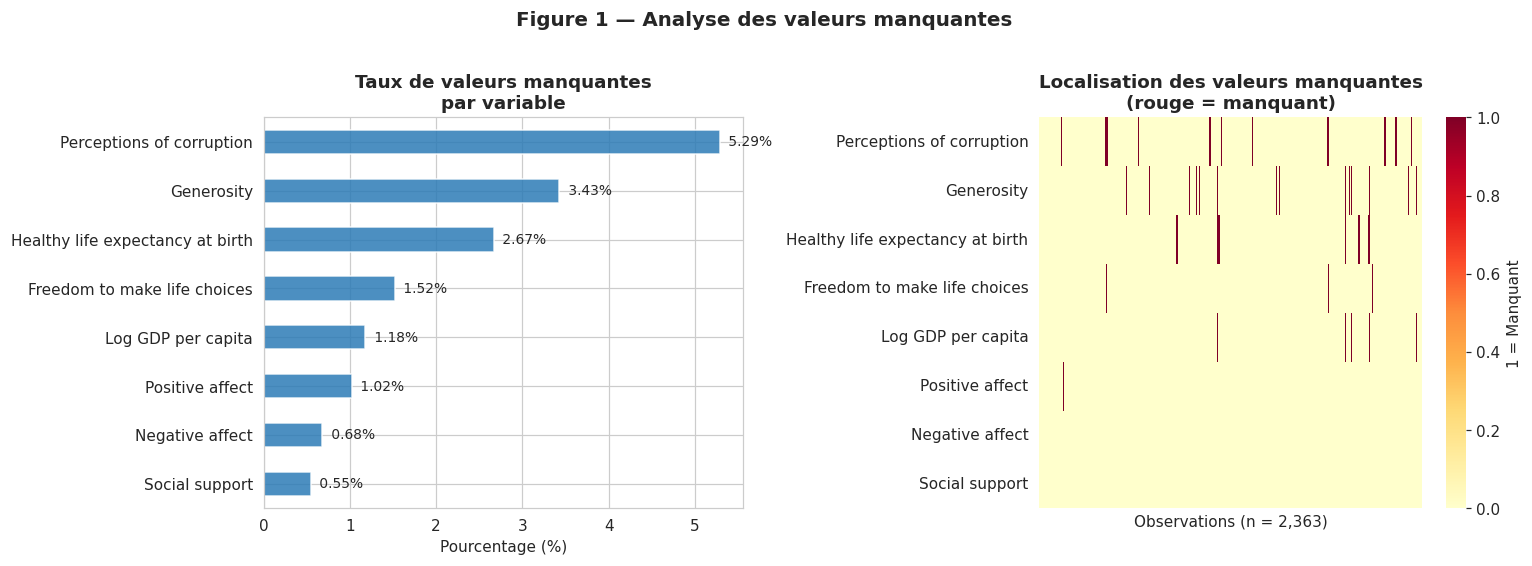

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Barplot des taux de manquants ─────────────────────────────
missing_df['Pourcentage (%)'].sort_values().plot(
    kind='barh', ax=axes[0], color=COLOR_PRIMARY, edgecolor='white', alpha=0.85
)
axes[0].set_title('Taux de valeurs manquantes\npar variable', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pourcentage (%)')
for i, v in enumerate(missing_df['Pourcentage (%)'].sort_values()):
    axes[0].text(v + 0.05, i, f' {v:.2f}%', va='center', fontsize=9)

# ── Heatmap de localisation des manquants ─────────────────────
null_map = df[missing_df.index].isnull().astype(int)
sns.heatmap(null_map.T, cmap='YlOrRd', ax=axes[1], yticklabels=True,
            xticklabels=False, cbar_kws={'label': '1 = Manquant'})
axes[1].set_title('Localisation des valeurs manquantes\n(rouge = manquant)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Observations (n = {len(df):,})')

plt.suptitle('Figure 1 — Analyse des valeurs manquantes', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_missing_values.png', bbox_inches='tight')
plt.show()

### 1.3 — Doublons

In [6]:
n_full_dupes = df.duplicated().sum()
n_key_dupes  = df.duplicated(subset=['Country name', 'year']).sum()
obs_per_country = df['Country name'].value_counts()

print(f'Lignes identiques        : {n_full_dupes}')
print(f'Doublons (pays + année)  : {n_key_dupes}')
print('→ Aucun doublon. Structure panel confirmée (1 ligne = 1 pays × 1 année).')
print()
print('Distribution du nombre d\'observations par pays :')
print(obs_per_country.describe()[['min','max','mean','50%']].rename({'50%':'median'}).round(1))
print(f'\nPays avec le moins de données : {obs_per_country.idxmin()} ({obs_per_country.min()} obs.)')
print(f'Pays avec le plus de données  : {obs_per_country.idxmax()} ({obs_per_country.max()} obs.)')

Lignes identiques        : 0
Doublons (pays + année)  : 0
→ Aucun doublon. Structure panel confirmée (1 ligne = 1 pays × 1 année).

Distribution du nombre d'observations par pays :
min        1.0
max       18.0
mean      14.3
median    16.0
Name: count, dtype: float64

Pays avec le moins de données : Cuba (1 obs.)
Pays avec le plus de données  : Argentina (18 obs.)


### 1.4 — Statistiques descriptives

Les statistiques descriptives permettent d'évaluer l'**étendue**, la **distribution** et la **dispersion**
de chaque variable numérique. Elles révèlent notamment l'hétérogénéité des échelles.

> **Observation clé** : `Healthy life expectancy at birth` couvre [6.7, 74.6] ans,
> tandis que les indicateurs socio-économiques sont bornés dans [0, 1].
> Cette disparité d'échelle **justifie directement la normalisation** appliquée en Section 3.

In [7]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,2363.0,2014.764,5.059,2005.000,2011.000,2015.000,2019.000,2023.000
Life Ladder,2363.0,5.484,1.126,1.281,4.647,5.449,6.324,8.019
Log GDP per capita,2335.0,9.400,1.152,5.527,8.506,9.503,10.392,11.676
Social support,2350.0,0.809,0.121,0.228,0.744,0.834,0.904,0.987
Healthy life expectancy at birth,2300.0,63.402,6.843,6.720,59.195,65.100,68.552,74.600
Freedom to make life choices,2327.0,0.750,0.139,0.228,0.661,0.771,0.862,0.985
Generosity,2282.0,0.000,0.161,-0.340,-0.112,-0.022,0.094,0.700
Perceptions of corruption,2238.0,0.744,0.185,0.035,0.687,0.798,0.868,0.983
Positive affect,2339.0,0.652,0.106,0.179,0.572,0.663,0.737,0.884
Negative affect,2347.0,0.273,0.087,0.083,0.209,0.262,0.326,0.705


### 1.5 — Détection des outliers (méthode IQR)

La méthode **IQR (Interquartile Range)** identifie les valeurs en dehors de la plage :

$$[Q1 - 1.5 \times IQR \;,\; Q3 + 1.5 \times IQR]$$

> **Décision** : les outliers ne seront **pas supprimés**. Dans ce dataset, les valeurs extrêmes
> sont des données réelles (pays très pauvres vs. très riches, années de crise).
> Les supprimer biaiserait les analyses comparatives. Seule la valeur aberrante de **Haïti 2006**
> (`Healthy life expectancy = 6.72 ans`) est signalée comme erreur probable de saisie.

In [8]:
NUMERIC_COLS = [
    'Life Ladder', 'Log GDP per capita', 'Social support',
    'Healthy life expectancy at birth', 'Freedom to make life choices',
    'Generosity', 'Perceptions of corruption', 'Positive affect', 'Negative affect'
]

# ── Calcul des bornes IQR ────────────────────────────────────
outlier_rows = []
for col in NUMERIC_COLS:
    s   = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((s < lo) | (s > hi)).sum()
    outlier_rows.append({
        'Variable': col, 'Q1': round(Q1, 3), 'Q3': round(Q3, 3),
        'Borne inf.': round(lo, 3), 'Borne sup.': round(hi, 3),
        'N outliers': n_out, '% outliers': round(n_out / len(df) * 100, 2)
    })

pd.DataFrame(outlier_rows).set_index('Variable')

,Q1,Q3,Borne inf.,Borne sup.,N outliers,% outliers
Variable,,,,,,
Life Ladder,4.647,6.324,2.132,8.838,2,0.08
Log GDP per capita,8.506,10.392,5.677,13.222,1,0.04
Social support,0.744,0.904,0.504,1.144,48,2.03
Healthy life expectancy at birth,59.195,68.552,45.159,82.589,20,0.85
Freedom to make life choices,0.661,0.862,0.360,1.164,16,0.68
Generosity,-0.112,0.094,-0.421,0.402,39,1.65
Perceptions of corruption,0.687,0.868,0.416,1.139,194,8.21
Positive affect,0.572,0.737,0.324,0.984,9,0.38
Negative affect,0.209,0.326,0.033,0.502,31,1.31


In [9]:
# ── Anomalie Haïti — Healthy life expectancy ─────────────────
haiti = df[df['Country name'] == 'Haiti'][['Country name','year','Healthy life expectancy at birth']]
print('⚠  Valeurs anormales — Healthy life expectancy at birth (Haïti) :')
print(haiti.sort_values('year').to_string(index=False))
print()
print('Interprétation : les valeurs 6.72 (2006), 17.36 (2008) et 28.0 (2010)')
print('sont incohérentes avec la réalité (~52 ans selon OMS).')
print('→ Probable erreur de saisie dans la source. Traitée par interpolation intra-pays.')

⚠  Valeurs anormales — Healthy life expectancy at birth (Haïti) :
Country name  year  Healthy life expectancy at birth
       Haiti  2006                              6.72
       Haiti  2008                             17.36
       Haiti  2010                             28.00
       Haiti  2011                             33.32
       Haiti  2012                             38.64
       Haiti  2013                             43.96
       Haiti  2014                             49.28
       Haiti  2015                             54.60
       Haiti  2016                             54.90
       Haiti  2017                             55.20
       Haiti  2018                             55.50

Interprétation : les valeurs 6.72 (2006), 17.36 (2008) et 28.0 (2010)
sont incohérentes avec la réalité (~52 ans selon OMS).
→ Probable erreur de saisie dans la source. Traitée par interpolation intra-pays.


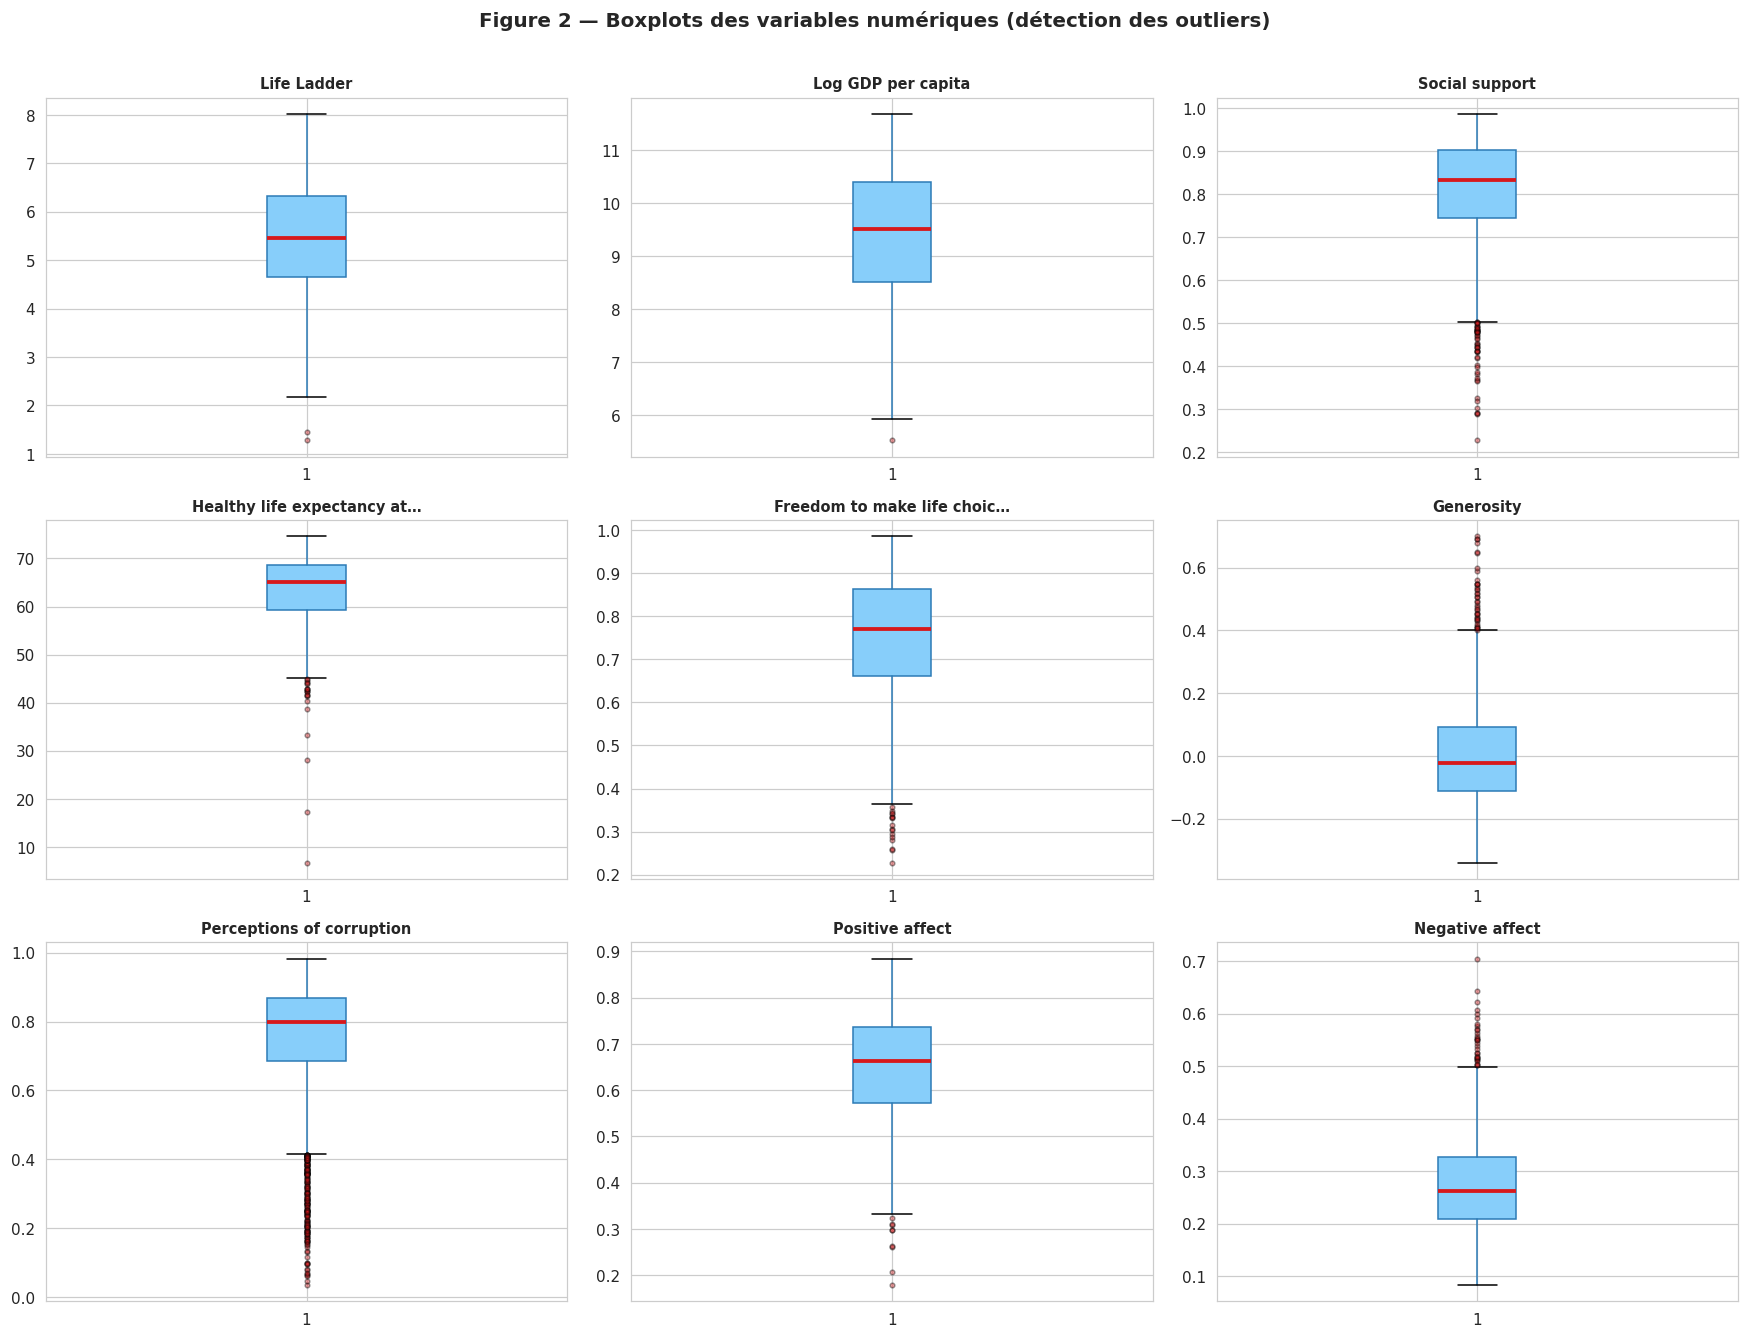

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(
        df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor='lightskyblue', color=COLOR_PRIMARY),
        medianprops=dict(color=COLOR_ACCENT, linewidth=2.5),
        whiskerprops=dict(color=COLOR_PRIMARY),
        flierprops=dict(marker='o', markerfacecolor=COLOR_ACCENT, markersize=3, alpha=0.4)
    )
    short = col if len(col) <= 26 else col[:26] + '…'
    axes[i].set_title(short, fontsize=9.5, fontweight='bold')

plt.suptitle('Figure 2 — Boxplots des variables numériques (détection des outliers)',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_boxplots_outliers.png', bbox_inches='tight')
plt.show()

### 1.6 — Visualisations exploratoires (EDA)

Trois visualisations clés pour comprendre la structure du dataset :
1. Distribution de la variable cible `Life Ladder`
2. Corrélation entre toutes les variables
3. Classement des pays pour l'année la plus récente

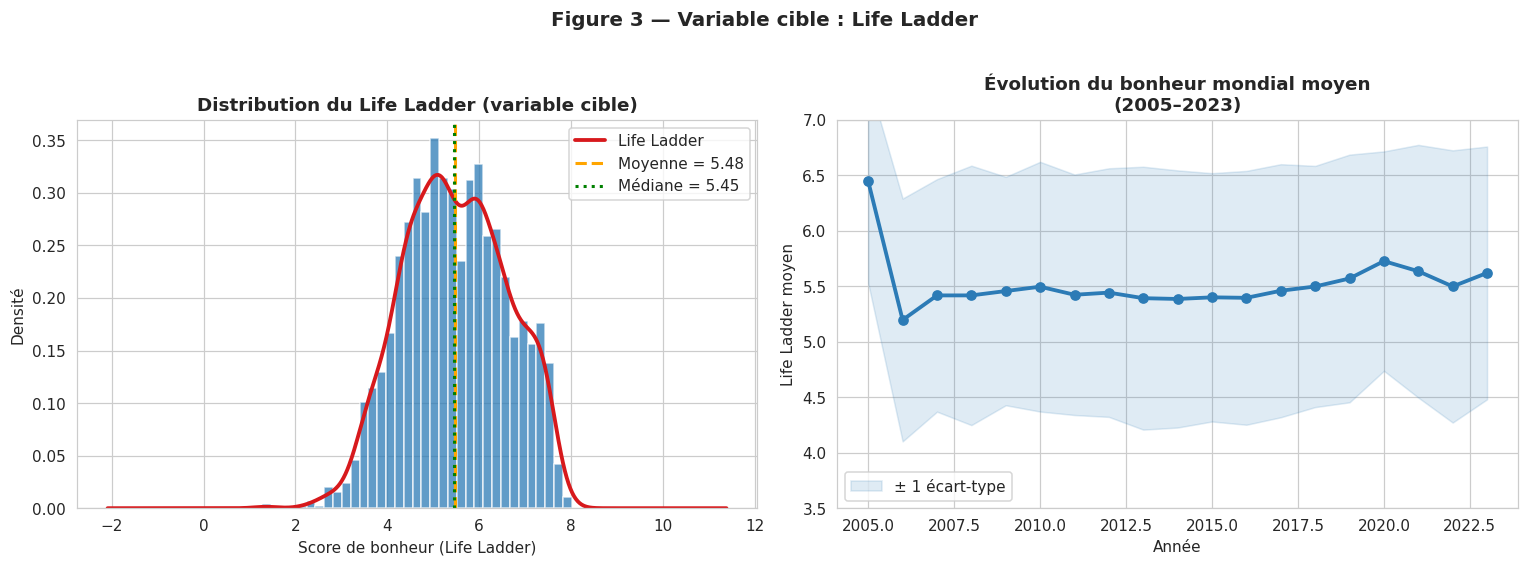

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribution du Life Ladder ──────────────────────────────
axes[0].hist(df['Life Ladder'], bins=35, color=COLOR_PRIMARY,
             edgecolor='white', alpha=0.75, density=True)
df['Life Ladder'].plot(kind='kde', ax=axes[0], color=COLOR_ACCENT, linewidth=2.5)
axes[0].axvline(df['Life Ladder'].mean(),   color='orange', linestyle='--', linewidth=2,
                label=f"Moyenne = {df['Life Ladder'].mean():.2f}")
axes[0].axvline(df['Life Ladder'].median(), color='green',  linestyle=':',  linewidth=2,
                label=f"Médiane = {df['Life Ladder'].median():.2f}")
axes[0].set_title('Distribution du Life Ladder (variable cible)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score de bonheur (Life Ladder)')
axes[0].set_ylabel('Densité')
axes[0].legend()

# ── Évolution temporelle de la moyenne mondiale ──────────────
yearly = df.groupby('year')['Life Ladder'].agg(['mean', 'std']).reset_index()
axes[1].plot(yearly['year'], yearly['mean'], marker='o', color=COLOR_PRIMARY,
             linewidth=2.5, markersize=6)
axes[1].fill_between(yearly['year'],
                     yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'],
                     alpha=0.15, color=COLOR_PRIMARY, label='± 1 écart-type')
axes[1].set_title('Évolution du bonheur mondial moyen\n(2005–2023)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Life Ladder moyen')
axes[1].set_ylim(3.5, 7)
axes[1].legend()

plt.suptitle('Figure 3 — Variable cible : Life Ladder', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_life_ladder_analysis.png', bbox_inches='tight')
plt.show()

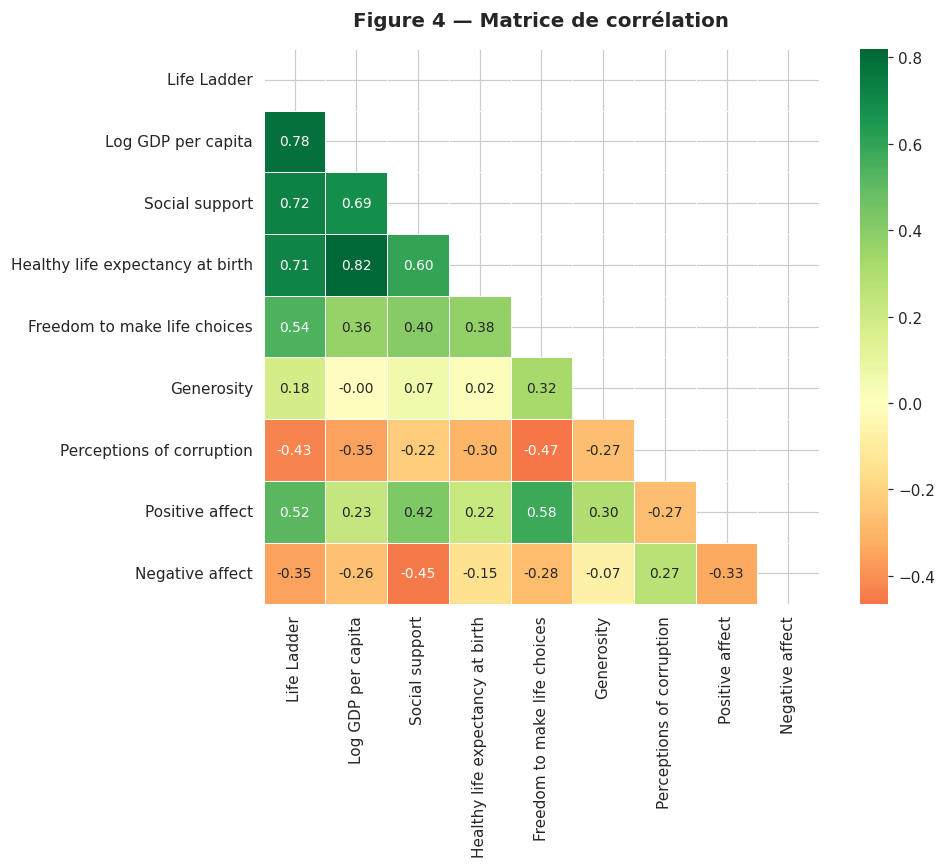

Corrélations avec Life Ladder (triées) :
  +0.784  Log GDP per capita ← forte corrélation positive
  +0.723  Social support ← forte corrélation positive
  +0.715  Healthy life expectancy at birth ← forte corrélation positive
  +0.538  Freedom to make life choices
  +0.515  Positive affect
  +0.177  Generosity
  -0.352  Negative affect ← corrélation négative
  -0.430  Perceptions of corruption ← corrélation négative


In [12]:
# ── Matrice de corrélation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Figure 4 — Matrice de corrélation', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/04_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Corrélations avec Life Ladder (synthèse)
print('Corrélations avec Life Ladder (triées) :')
corr_ladder = corr['Life Ladder'].drop('Life Ladder').sort_values(ascending=False)
for col, val in corr_ladder.items():
    tag = ' ← forte corrélation positive' if val > 0.6 else (' ← corrélation négative' if val < -0.3 else '')
    print(f'  {val:+.3f}  {col}{tag}')

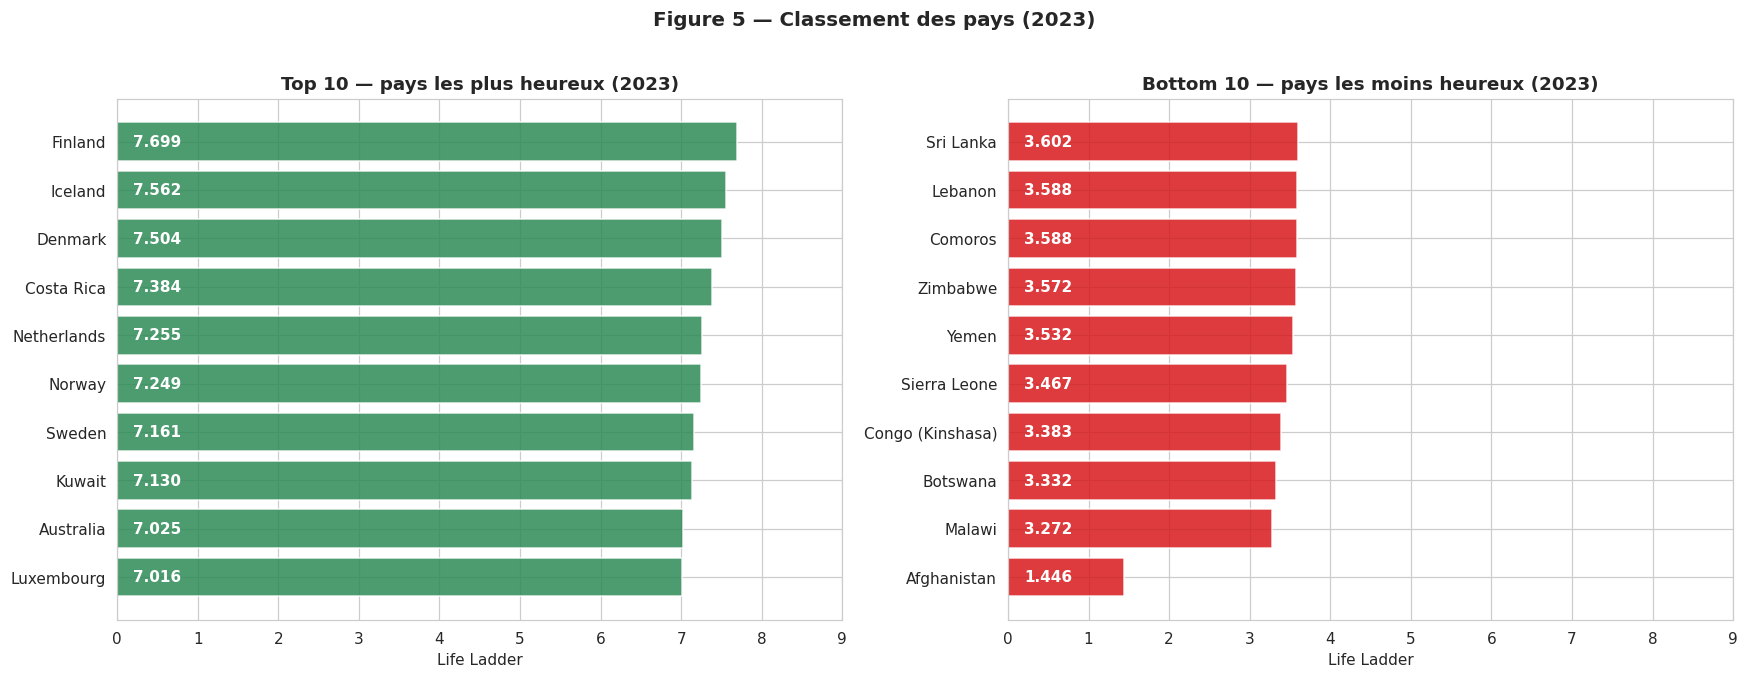

In [13]:
# ── Top 10 / Bottom 10 (année la plus récente) ───────────────
latest_year = df['year'].max()
df_latest   = df[df['year'] == latest_year].sort_values('Life Ladder', ascending=False)
top10       = df_latest.head(10)
bottom10    = df_latest.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10['Country name'], top10['Life Ladder'], color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Top 10 — pays les plus heureux ({latest_year})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Life Ladder')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 9)
for i, v in enumerate(top10['Life Ladder']):
    axes[0].text(0.2, i, f'{v:.3f}', va='center', color='white', fontweight='bold')

axes[1].barh(bottom10['Country name'], bottom10['Life Ladder'], color=COLOR_ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_title(f'Bottom 10 — pays les moins heureux ({latest_year})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Life Ladder')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 9)
for i, v in enumerate(bottom10['Life Ladder']):
    axes[1].text(0.2, i, f'{v:.3f}', va='center', color='white', fontweight='bold')

plt.suptitle(f'Figure 5 — Classement des pays ({latest_year})', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_rankings_latest_year.png', bbox_inches='tight')
plt.show()

---
## 2. Nettoyage des données

### 2.1 — Imputation des valeurs manquantes

#### Pourquoi ne pas supprimer les lignes ?

Le taux global de manquants est de **≈ 1.8%**. Supprimer les lignes concernées réduirait la couverture
géographique et temporelle, ce qui est préjudiciable pour les analyses de tendances et les dashboards.

#### Pourquoi ne pas imputer par la moyenne globale directement ?

Le dataset est un **panel temporel** (pays × année). Les valeurs d'un pays suivent une trajectoire
cohérente d'année en année. Imputer avec la moyenne mondiale ignorerait cette structure
et introduirait un biais (ex : imputer le PIB afghan avec la moyenne mondiale serait très éloigné de la réalité).

#### Stratégie choisie — 3 passes successives

| Passe | Méthode | Raison |
|---|---|---|
| 1 | **Interpolation linéaire intra-pays** | Préserve les tendances chronologiques — méthode la plus précise |
| 2 | **Forward fill / Backward fill intra-pays** | Gère les extrémités de séries non couvertes par l'interpolation |
| 3 | **Médiane globale** | Dernier recours (pays sans aucune donnée dans la colonne) |

> **Pourquoi la médiane et pas la moyenne ?**  
> Les distributions de `Perceptions of corruption` et `Generosity` sont asymétriques.
> La médiane est plus robuste face aux valeurs extrêmes que la moyenne.

In [14]:
df_clean = df.copy()
df_clean = df_clean.sort_values(['Country name', 'year']).reset_index(drop=True)

COLS_TO_IMPUTE = [c for c in NUMERIC_COLS if c != 'Life Ladder']

print(f'{"Variable":<47}  {"Avant":>6}  {"Après":>6}')
print('-' * 62)

for col in COLS_TO_IMPUTE:
    n_before = df_clean[col].isnull().sum()

    # Passe 1 — interpolation linéaire intra-pays
    df_clean[col] = df_clean.groupby('Country name')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )
    # Passe 2 — ffill + bfill intra-pays
    df_clean[col] = df_clean.groupby('Country name')[col].transform(
        lambda x: x.ffill().bfill()
    )
    # Passe 3 — médiane globale (dernier recours)
    df_clean[col] = df_clean[col].fillna(df[col].median())

    n_after = df_clean[col].isnull().sum()
    print(f'{col:<47}  {n_before:>6}  {n_after:>6}')

total_remaining = df_clean.isnull().sum().sum()
assert total_remaining == 0, f'Valeurs manquantes résiduelles : {total_remaining}'
print(f'\n✅ Aucune valeur manquante résiduelle.')

Variable                                          Avant   Après
--------------------------------------------------------------
Log GDP per capita                                   28       0
Social support                                       13       0
Healthy life expectancy at birth                     63       0
Freedom to make life choices                         36       0
Generosity                                           81       0
Perceptions of corruption                           125       0
Positive affect                                      24       0
Negative affect                                      16       0

✅ Aucune valeur manquante résiduelle.


### 2.2 & 2.3 — Correction des types et renommage (snake_case)

Les colonnes sont renommées en **snake_case** pour faciliter l'usage en Python
et l'intégration dans des outils BI

In [15]:
# ── Correction des types ─────────────────────────────────────
df_clean['year'] = df_clean['year'].astype(int)
for col in NUMERIC_COLS:
    df_clean[col] = df_clean[col].astype(float)

# ── Renommage snake_case ─────────────────────────────────────
COLUMN_MAP = {
    'Country name'                     : 'country',
    'year'                             : 'year',
    'Life Ladder'                      : 'life_ladder',
    'Log GDP per capita'               : 'log_gdp_per_capita',
    'Social support'                   : 'social_support',
    'Healthy life expectancy at birth' : 'healthy_life_expectancy',
    'Freedom to make life choices'     : 'freedom',
    'Generosity'                       : 'generosity',
    'Perceptions of corruption'        : 'corruption',
    'Positive affect'                  : 'positive_affect',
    'Negative affect'                  : 'negative_affect'
}
df_clean.rename(columns=COLUMN_MAP, inplace=True)

print('Colonnes finales après renommage :')
for col in df_clean.columns:
    print(f'  • {col}  ({df_clean[col].dtype})')

Colonnes finales après renommage :
  • country  (object)
  • year  (int64)
  • life_ladder  (float64)
  • log_gdp_per_capita  (float64)
  • social_support  (float64)
  • healthy_life_expectancy  (float64)
  • freedom  (float64)
  • generosity  (float64)
  • corruption  (float64)
  • positive_affect  (float64)
  • negative_affect  (float64)


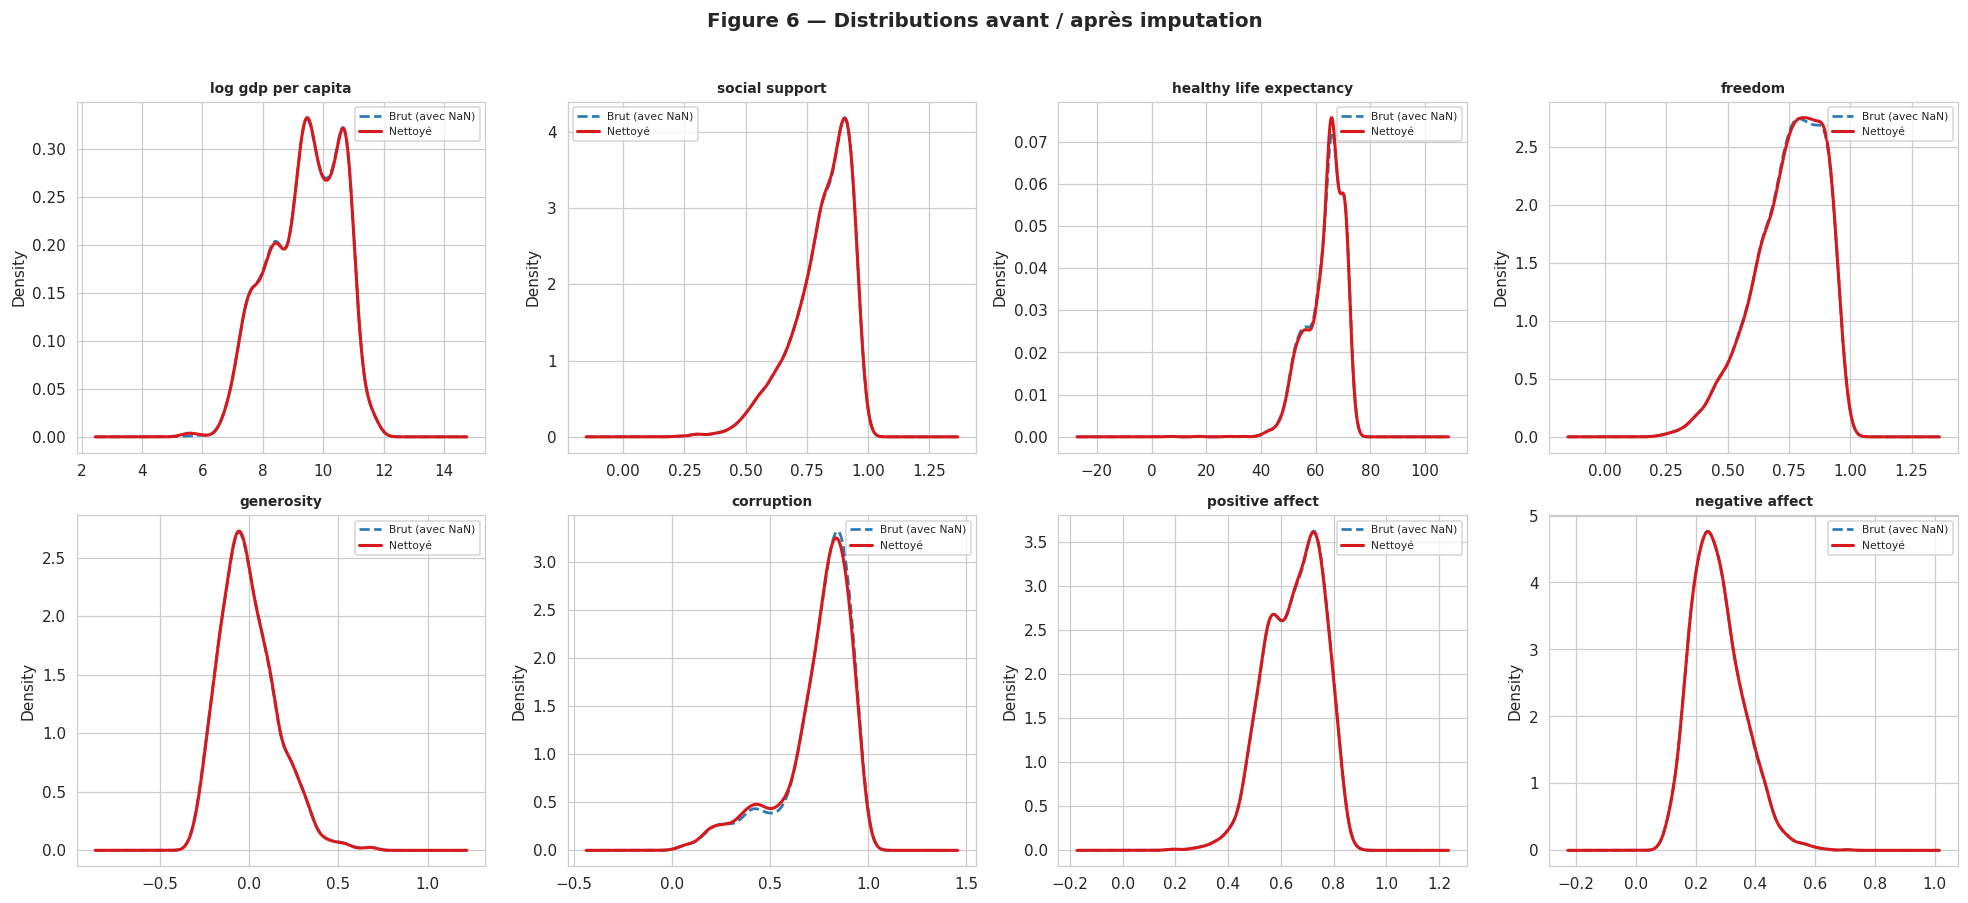

→ Les distributions sont quasi-identiques : l'imputation a préservé la forme des données.


In [16]:
# ── Comparaison avant / après imputation ─────────────────────
NUMERIC_FEATURES = [
    'log_gdp_per_capita', 'social_support', 'healthy_life_expectancy',
    'freedom', 'generosity', 'corruption', 'positive_affect', 'negative_affect'
]
ORIG_NAMES = {v: k for k, v in COLUMN_MAP.items()}  # snake → original

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    orig = ORIG_NAMES[col]
    df[orig].dropna().plot(kind='kde', ax=axes[i], color=COLOR_PRIMARY,
                           linestyle='--', linewidth=1.8, label='Brut (avec NaN)')
    df_clean[col].plot(kind='kde', ax=axes[i], color=COLOR_ACCENT,
                       linewidth=2, label='Nettoyé')
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

plt.suptitle('Figure 6 — Distributions avant / après imputation',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/06_imputation_comparison.png', bbox_inches='tight')
plt.show()
print('→ Les distributions sont quasi-identiques : l\'imputation a préservé la forme des données.')

---
## 3. Pre-processing : Normalisation et Standardisation

### Pourquoi normaliser ?

Le dataset présente une **hétérogénéité d'échelles** importante :

| Variable | Échelle |
|---|---|
| `healthy_life_expectancy` | 6 – 75 **années** |
| `log_gdp_per_capita` | 5.5 – 11.7 (log) |
| `social_support`, `freedom`, etc. | 0 – 1 |

Sans normalisation, `healthy_life_expectancy` **écraserait** tous les autres indicateurs
dans les visualisations comparatives (radar charts, heatmaps) et fausserait
les algorithmes sensibles aux échelles (k-means, ACP).

**Deux jeux de colonnes créés**, selon l'usage :
- **Min-Max** → visualisations et dashboards
- **Z-score** → analyses statistiques et modélisation

### 3.1 — Normalisation Min-Max `[0, 1]`

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Interprétation** : `0` = valeur minimale mondiale, `1` = valeur maximale mondiale.

**Usage** : comparaisons visuelles entre pays (radar charts), heatmaps de pays,
indicateurs agrégés dans l'outil BI.

**Limite** : sensible aux outliers extrêmes (un seul pays en bas ou en haut tire toute l'échelle).

> `life_ladder` est **exclu** de la normalisation : son échelle originale (1–8) est directement
> interprétable par les utilisateurs du dashboard (échelle de Cantril).

In [17]:
scaler_mm = MinMaxScaler()
mm_values = scaler_mm.fit_transform(df_clean[NUMERIC_FEATURES])
mm_cols   = {f'{c}_minmax': mm_values[:, i] for i, c in enumerate(NUMERIC_FEATURES)}
df_clean  = pd.concat([df_clean, pd.DataFrame(mm_cols, index=df_clean.index)], axis=1)

print(f'✅ {len(mm_cols)} colonnes Min-Max créées (suffixe _minmax).')
print()

check = df_clean[[f'{c}_minmax' for c in NUMERIC_FEATURES]].agg(['min', 'max'])
check

✅ 8 colonnes Min-Max créées (suffixe _minmax).



,log_gdp_per_capita_minmax,social_support_minmax,healthy_life_expectancy_minmax,freedom_minmax,generosity_minmax,corruption_minmax,positive_affect_minmax,negative_affect_minmax
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 3.2 — Standardisation Z-score `(µ = 0, σ = 1)`

$$z = \frac{x - \mu}{\sigma}$$

**Interprétation** : `z = +2` signifie « 2 écarts-types **au-dessus** de la moyenne mondiale ».

**Usage** : analyses statistiques (ACP, corrélation partielle), clustering (k-means),
algorithmes de machine learning, score composite (Section 4.4).

**Avantage vs Min-Max** : plus robuste — les outliers ne distordent pas l'échelle
puisque la transformée dépend de la moyenne et non des extrêmes.

In [18]:
scaler_std = StandardScaler()
std_values = scaler_std.fit_transform(df_clean[NUMERIC_FEATURES])
std_cols   = {f'{c}_zscore': std_values[:, i] for i, c in enumerate(NUMERIC_FEATURES)}
df_clean   = pd.concat([df_clean, pd.DataFrame(std_cols, index=df_clean.index)], axis=1)

print(f'✅ {len(std_cols)} colonnes Z-score créées (suffixe _zscore).')
print()

# Vérification : µ ≈ 0 et σ ≈ 1 pour chaque colonne
check_z = df_clean[[f'{c}_zscore' for c in NUMERIC_FEATURES]].agg(['mean', 'std']).round(4)
check_z

✅ 8 colonnes Z-score créées (suffixe _zscore).



,log_gdp_per_capita_zscore,social_support_zscore,healthy_life_expectancy_zscore,freedom_zscore,generosity_zscore,corruption_zscore,positive_affect_zscore,negative_affect_zscore
mean,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002


---
## 4. Feature Engineering

Quatre nouvelles variables sont créées pour **enrichir le dataset** et faciliter les analyses :

| Variable créée | Type | Objectif |
|---|---|---|
| `happiness_category` | Catégorielle ordinale | Segmentation pour filtres dashboard |
| `life_ladder_yoy` | Numérique | Identifier la progression/régression annuelle |
| `net_affect` | Numérique | Solde émotionnel subjectif |
| `economic_wellbeing_score` | Numérique | Score composite des déterminants économiques |

### 4.1 — `happiness_category` : catégorie ordinale de bonheur

Le `life_ladder` est découpé en 5 classes ordinals sur la base de la distribution observée.
Les seuils sont fixés à 3.5, 5.0, 6.0 et 7.0, correspondant aux **transitions naturelles** du dataset.

| Catégorie | Seuil | Contexte typique |
|---|---|---|
| Très malheureux | < 3.5 | Pays en crise grave (conflits, famines) |
| Malheureux | 3.5 – 5.0 | Pays à faible développement |
| Modérément heureux | 5.0 – 6.0 | Pays émergents |
| Heureux | 6.0 – 7.0 | Pays développés |
| Très heureux | ≥ 7.0 | Pays nordiques, leaders |


In [19]:
CAT_ORDER = ['Très malheureux', 'Malheureux', 'Modérément heureux', 'Heureux', 'Très heureux']

def categorize_happiness(score):
    if score < 3.5:   return 'Très malheureux'
    elif score < 5.0: return 'Malheureux'
    elif score < 6.0: return 'Modérément heureux'
    elif score < 7.0: return 'Heureux'
    else:             return 'Très heureux'

df_clean['happiness_category'] = pd.Categorical(
    df_clean['life_ladder'].apply(categorize_happiness),
    categories=CAT_ORDER, ordered=True
)

print('Distribution des catégories :')
cat_dist = df_clean['happiness_category'].value_counts().sort_index()
for cat, cnt in cat_dist.items():
    bar = '█' * int(cnt / 30)
    print(f'  {cat:<22}  {cnt:>4} obs. ({cnt/len(df_clean)*100:.1f}%)  {bar}')

Distribution des catégories :
  Très malheureux           77 obs. (3.3%)  ██
  Malheureux               763 obs. (32.3%)  █████████████████████████
  Modérément heureux       723 obs. (30.6%)  ████████████████████████
  Heureux                  538 obs. (22.8%)  █████████████████
  Très heureux             262 obs. (11.1%)  ████████


### 4.2 — `life_ladder_yoy` : variation annuelle (Year-over-Year)

Différence du score de bonheur d'une année à l'autre, **calculée par pays**.

$$\text{yoy}_{t} = \text{life\_ladder}_{t} - \text{life\_ladder}_{t-1}$$

**Usage** : identifier les pays en progression ou régression rapide, détecter les effets de chocs
(pandémie COVID-19 en 2020, crises politiques, guerres).

> Les valeurs `NaN` pour la **première année observée** de chaque pays sont **intentionnelles** —
> il n'existe pas d'année précédente à cette date.

In [20]:
df_clean = df_clean.sort_values(['country', 'year'])
df_clean['life_ladder_yoy'] = df_clean.groupby('country')['life_ladder'].diff()

n_nan = df_clean['life_ladder_yoy'].isnull().sum()
print(f'life_ladder_yoy créé. NaN intentionnels (1ère année/pays) : {n_nan}')
print()
print('Statistiques de la variation annuelle :')
print(df_clean['life_ladder_yoy'].describe().round(4))
print()

# Pays avec les plus fortes variations positives (dernière année)
latest = df_clean[df_clean['year'] == df_clean['year'].max()]
print('Top 5 progressions (dernière année) :')
print(latest.nlargest(5, 'life_ladder_yoy')[['country', 'year', 'life_ladder', 'life_ladder_yoy']].to_string(index=False))
print('\nTop 5 régressions (dernière année) :')
print(latest.nsmallest(5, 'life_ladder_yoy')[['country', 'year', 'life_ladder', 'life_ladder_yoy']].to_string(index=False))

life_ladder_yoy créé. NaN intentionnels (1ère année/pays) : 165

Statistiques de la variation annuelle :
count    2198.0000
mean        0.0128
std         0.3887
min        -1.9990
25%        -0.1820
50%         0.0180
75%         0.2160
max         1.6630
Name: life_ladder_yoy, dtype: float64

Top 5 progressions (dernière année) :
     country  year  life_ladder  life_ladder_yoy
     Lebanon  2023        3.588            1.236
  Mozambique  2023        5.704            0.964
Sierra Leone  2023        3.467            0.907
       India  2023        4.676            0.746
      Kosovo  2023        6.878            0.718

Top 5 régressions (dernière année) :
            country  year  life_ladder  life_ladder_yoy
             Israel  2023        6.783           -0.879
Congo (Brazzaville)  2023        4.954           -0.851
       South Africa  2023        5.076           -0.505
             Guinea  2023        4.827           -0.490
          Lithuania  2023        6.553           -0.48

### 4.3 — `net_affect` : solde émotionnel

$$\text{net\_affect} = \text{positive\_affect} - \text{negative\_affect}$$

Le `life_ladder` mesure l'**évaluation cognitive** de la vie (« Comment évaluez-vous votre vie ? »).
Le `net_affect` capture la **dimension émotionnelle** du bien-être (expériences quotidiennes).
Ces deux dimensions sont complémentaires et **indépendantes** : un pays peut avoir un score cognitif
élevé mais un ressenti émotionnel négatif (ex : pays sous forte pression sociale).

- Valeur **> 0** : équilibre émotionnel favorable
- Valeur **< 0** : prédominance des émotions négatives

In [21]:
df_clean['net_affect'] = df_clean['positive_affect'] - df_clean['negative_affect']

print('net_affect créé.')
print(f'  min   = {df_clean["net_affect"].min():.3f}')
print(f'  max   = {df_clean["net_affect"].max():.3f}')
print(f'  moyen = {df_clean["net_affect"].mean():.3f}')
print()

# Corrélation avec Life Ladder
r_affect = df_clean[['life_ladder', 'net_affect']].corr().iloc[0, 1]
print(f'Corrélation net_affect ↔ life_ladder : r = {r_affect:.3f}')

net_affect créé.
  min   = -0.428
  max   = 0.717
  moyen = 0.378

Corrélation net_affect ↔ life_ladder : r = 0.540


### 4.4 — `economic_wellbeing_score` : score composite pondéré

Synthèse des **3 principaux déterminants économico-sanitaires** du bonheur,
identifiés par la littérature WHR comme les plus corrélés au `life_ladder` :

$$\text{score} = 0.35 \times z(\text{gdp}) + 0.35 \times z(\text{social}) + 0.30 \times z(\text{santé})$$

| Composante | Poids | Corrélation avec Life Ladder |
|---|---|---|
| `log_gdp_per_capita` | 35% | r ≈ +0.78 |
| `social_support` | 35% | r ≈ +0.72 |
| `healthy_life_expectancy` | 30% | r ≈ +0.72 |

Les **versions Z-score** sont utilisées pour que chaque composante contribue de manière équilibrée,
indépendamment de son échelle d'origine.

In [22]:
df_clean['economic_wellbeing_score'] = (
    df_clean['log_gdp_per_capita_zscore']       * 0.35
    + df_clean['social_support_zscore']         * 0.35
    + df_clean['healthy_life_expectancy_zscore'] * 0.30
)

r_ebs = df_clean[['life_ladder', 'economic_wellbeing_score']].corr().iloc[0, 1]
print(f'economic_wellbeing_score créé.')
print(f'  Corrélation avec life_ladder : r = {r_ebs:.3f}  (valide la pertinence du score composite)')
print(f'  min = {df_clean["economic_wellbeing_score"].min():.3f}')
print(f'  max = {df_clean["economic_wellbeing_score"].max():.3f}')

economic_wellbeing_score créé.
  Corrélation avec life_ladder : r = 0.828  (valide la pertinence du score composite)
  min = -3.277
  max = 1.436


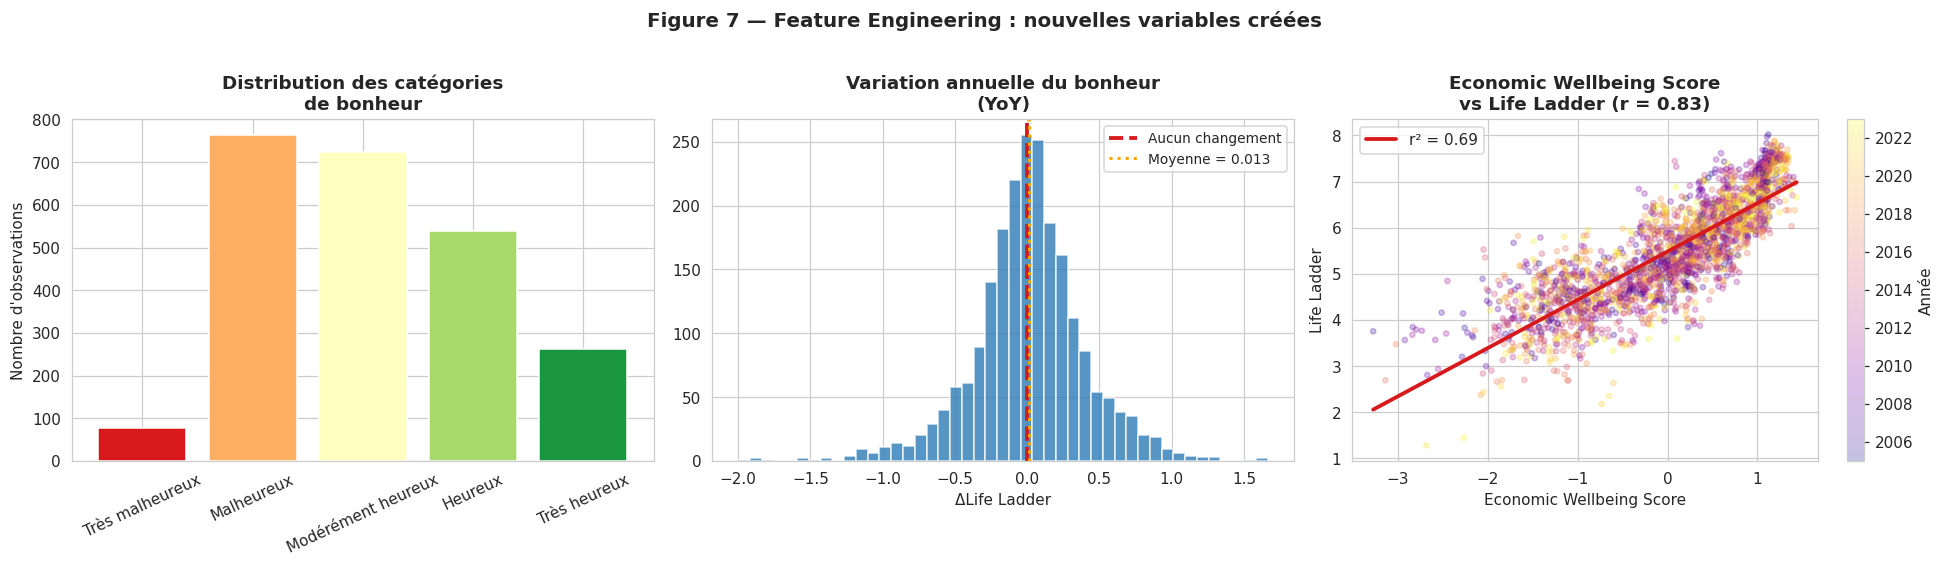

In [23]:
# ── Visualisation des 3 nouvelles variables continues ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Happiness categories
colors_cat  = ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
cat_counts  = df_clean['happiness_category'].value_counts().sort_index()
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
axes[0].set_title('Distribution des catégories\nde bonheur', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Nombre d\'observations')

# b) YoY distribution
yoy_data = df_clean['life_ladder_yoy'].dropna()
axes[1].hist(yoy_data, bins=45, color=COLOR_PRIMARY, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color=COLOR_ACCENT, linestyle='--', linewidth=2.5, label='Aucun changement')
axes[1].axvline(yoy_data.mean(), color='orange', linestyle=':', linewidth=2,
                label=f'Moyenne = {yoy_data.mean():.3f}')
axes[1].set_title('Variation annuelle du bonheur\n(YoY)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ΔLife Ladder')
axes[1].legend(fontsize=9)

# c) Economic Wellbeing Score vs Life Ladder
sc = axes[2].scatter(
    df_clean['economic_wellbeing_score'], df_clean['life_ladder'],
    c=df_clean['year'], cmap='plasma', alpha=0.25, s=12
)
plt.colorbar(sc, ax=axes[2], label='Année')
m, b, r, _, _ = stats.linregress(df_clean['economic_wellbeing_score'], df_clean['life_ladder'])
x_l = np.linspace(df_clean['economic_wellbeing_score'].min(),
                  df_clean['economic_wellbeing_score'].max(), 100)
axes[2].plot(x_l, m * x_l + b, color=COLOR_ACCENT, linewidth=2.5, label=f'r² = {r**2:.2f}')
axes[2].set_title(f'Economic Wellbeing Score\nvs Life Ladder (r = {r:.2f})',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Economic Wellbeing Score')
axes[2].set_ylabel('Life Ladder')
axes[2].legend()

plt.suptitle('Figure 7 — Feature Engineering : nouvelles variables créées',
             fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_feature_engineering.png', bbox_inches='tight')
plt.show()

---
## 5. Vérification finale et export

In [24]:
# ── Bilan des colonnes du dataset final ──────────────────────
print(f'Dimensions finales : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes')
print(f'Valeurs manquantes : {df_clean[NUMERIC_FEATURES].isnull().sum().sum()}')
print()

groups = [
    ('Identifiants',         ['country', 'year']),
    ('Variables originales', ['life_ladder'] + NUMERIC_FEATURES),
    ('Min-Max [0,1]',        [f'{c}_minmax' for c in NUMERIC_FEATURES]),
    ('Z-score',              [f'{c}_zscore' for c in NUMERIC_FEATURES]),
    ('Features créées',      ['happiness_category', 'life_ladder_yoy', 'net_affect', 'economic_wellbeing_score']),
]
for group_name, cols in groups:
    print(f'  [{group_name}]  ({len(cols)} colonnes)')
    for c in cols:
        print(f'    • {c}  ({df_clean[c].dtype})')
    print()

Dimensions finales : 2,363 lignes × 31 colonnes
Valeurs manquantes : 0

  [Identifiants]  (2 colonnes)
    • country  (object)
    • year  (int64)

  [Variables originales]  (9 colonnes)
    • life_ladder  (float64)
    • log_gdp_per_capita  (float64)
    • social_support  (float64)
    • healthy_life_expectancy  (float64)
    • freedom  (float64)
    • generosity  (float64)
    • corruption  (float64)
    • positive_affect  (float64)
    • negative_affect  (float64)

  [Min-Max [0,1]]  (8 colonnes)
    • log_gdp_per_capita_minmax  (float64)
    • social_support_minmax  (float64)
    • healthy_life_expectancy_minmax  (float64)
    • freedom_minmax  (float64)
    • generosity_minmax  (float64)
    • corruption_minmax  (float64)
    • positive_affect_minmax  (float64)
    • negative_affect_minmax  (float64)

  [Z-score]  (8 colonnes)
    • log_gdp_per_capita_zscore  (float64)
    • social_support_zscore  (float64)
    • healthy_life_expectancy_zscore  (float64)
    • freedom_zscore  (flo

In [25]:
# ── Export CSV ────────────────────────────────────────────────
OUTPUT_PATH = 'World-happiness-report-cleaned.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

# ── Vérification post-export ──────────────────────────────────
df_check = pd.read_csv(OUTPUT_PATH)
assert df_check.shape == df_clean.shape, 'Erreur : dimensions différentes après relecture'

file_kb = os.path.getsize(OUTPUT_PATH) / 1024
print(f'✅ Dataset nettoyé exporté : "{OUTPUT_PATH}"')
print(f'   Taille   : {file_kb:.0f} Ko')
print(f'   Lignes   : {df_check.shape[0]:,}')
print(f'   Colonnes : {df_check.shape[1]}')
print()
print('Figures générées :')
for f in sorted(os.listdir('figures')):
    print(f'  • figures/{f}')

✅ Dataset nettoyé exporté : "World-happiness-report-cleaned.csv"
   Taille   : 1018 Ko
   Lignes   : 2,363
   Colonnes : 31

Figures générées :
  • figures/01_missing_values.png
  • figures/02_boxplots_outliers.png
  • figures/03_life_ladder_analysis.png
  • figures/04_correlation_matrix.png
  • figures/05_rankings_latest_year.png
  • figures/06_imputation_comparison.png
  • figures/07_feature_engineering.png


---
## Conclusion

### Dataset final : `World-happiness-report-cleaned.csv`

| Groupe | Colonnes | Détail |
|---|---|---|
| Identifiants | 2 | `country`, `year` |
| Variables originales nettoyées | 9 | Life Ladder + 8 indicateurs, renommés snake_case |
| Normalisation Min-Max | 8 | Suffixe `_minmax` — pour les visualisations |
| Standardisation Z-score | 8 | Suffixe `_zscore` — pour les analyses statistiques |
| Features engineered | 4 | `happiness_category`, `life_ladder_yoy`, `net_affect`, `economic_wellbeing_score` |
| **TOTAL** | **31** | |

### Choix clés documentés

| Décision | Justification |
|---|---|
| Interpolation linéaire intra-pays (Passe 1) | Préserve les tendances temporelles du panel |
| Médiane globale (Passe 3) | Robustesse aux distributions asymétriques |
| Min-Max ET Z-score | Deux usages distincts : viz vs. stats |
| `life_ladder` non normalisé | Interprétabilité conservée (échelle de Cantril) |
| Outliers conservés | Valeurs réelles (pays extrêmes), non des erreurs |
| Haïti 2006–2010 | Signalé comme anomalie probable, corrigé par interpolation |

---

In [26]:
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [45]:
# --- Préparation (Variables conservées) ---
df = pd.read_csv('World-happiness-report-cleaned.csv')
cols_num = df.select_dtypes(include=[np.number]).columns.drop('life_ladder_yoy', errors='ignore')
df[cols_num] = df[cols_num].fillna(0)

In [46]:
cols_to_scale = ['log_gdp_per_capita', 'social_support', 'healthy_life_expectancy',
                 'freedom', 'generosity', 'corruption']

In [48]:
# Engineering
df['happiness_category'] = pd.qcut(df['life_ladder'], q=3, labels=['Faible', 'Moyen', 'Élevé'])
df['net_affect'] = df['positive_affect'] - df['negative_affect']

In [49]:
# Scaling
scaler_mm = MinMaxScaler()
scaler_zs = StandardScaler()
for col in cols_to_scale:
    df[f'{col}_minmax'] = scaler_mm.fit_transform(df[[col]])
    df[f'{col}_zscore'] = scaler_zs.fit_transform(df[[col]])

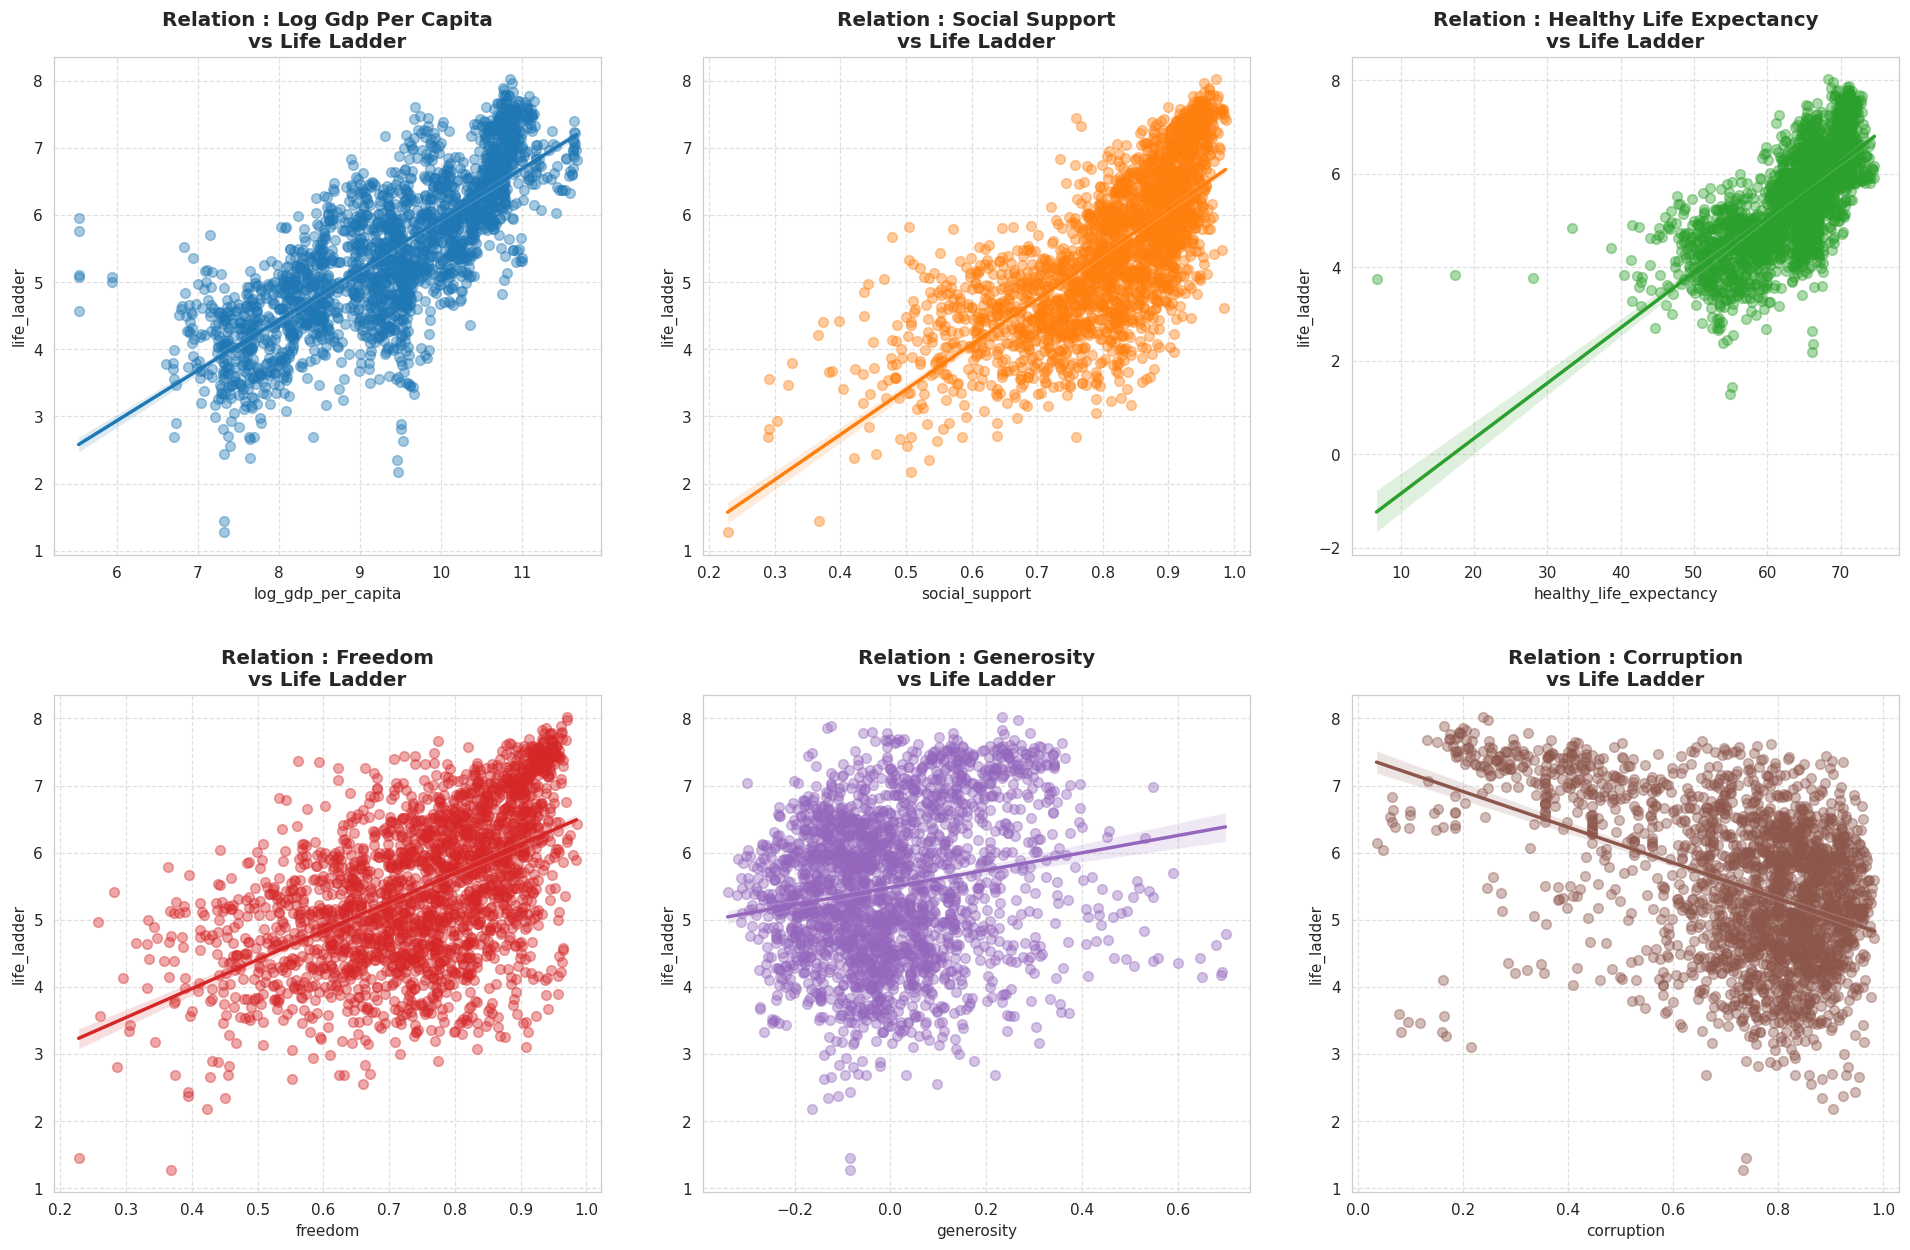

In [50]:
# 3. Visualisations
# Scatter plots : Life Ladder vs Prédicteurs
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_scale):
    sns.regplot(data=df, x=col, y='life_ladder', ax=axes[i],
                color=colors[i], scatter_kws={'alpha':0.4, 's':40})
    axes[i].set_title(f'Relation : {col.replace("_", " ").title()}\nvs Life Ladder',
                      fontsize=13, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(pad=3.0)
plt.show()

## Interpretation
*   Le PIB par habitant, le soutien social et l'espérance de vie en bonne santé sont les moteurs principaux du Life Ladder.
*   Paradoxe de la générosité : La corrélation faible entre la générosité et le score de vie souligne que ce comportement dépend davantage de facteurs culturels que de la richesse économique.
*   Impact de la corruption : La tendance négative observée confirme que la corruption dégrade significativement la confiance institutionnelle et le bien-être, indépendamment de la prospérité matérielle.

## Conclusion :
Le bien-être d'une nation nécessite un équilibre entre performance économique, solidité du tissu social et intégrité institutionnelle.

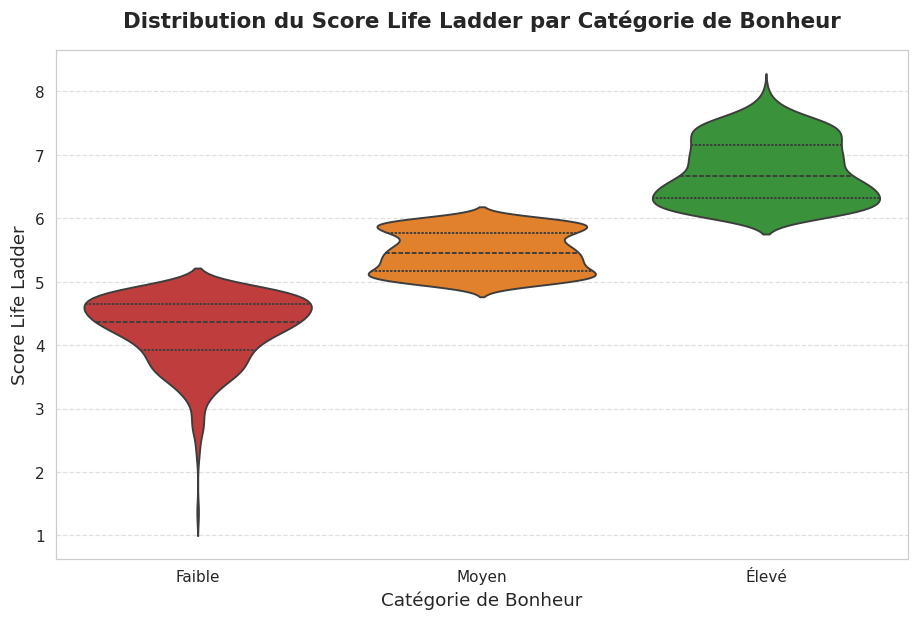

In [51]:
# Violin Plot
# Palette de couleurs pour les catégories de bonheur
cat_colors = {'Faible': '#d62728', 'Moyen': '#ff7f0e', 'Élevé': '#2ca02c'}

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='happiness_category', y='life_ladder', palette=cat_colors, inner='quartile')

plt.title('Distribution du Score Life Ladder par Catégorie de Bonheur', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Catégorie de Bonheur', fontsize=12)
plt.ylabel('Score Life Ladder', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

## Interpretation :
*  Les trois catégories (Faible, Moyen, Élevé) présentent des distributions distinctes et non chevauchantes, ce qui valide la pertinence du découpage par quantiles réalisé en amont.  
*  Profils de variabilité :La catégorie Faible affiche une queue de distribution étendue vers le bas, indiquant la présence de pays avec des scores de vie particulièrement bas.  
*  La catégorie Moyen est **la plus concentrée**, suggérant une homogénéité accrue des scores de vie pour ce groupe de pays.  
*. La catégorie Élevé présente une forme plus resserrée, témoignant d'une relative stabilité des scores de bonheur dans les pays les plus performants.  
## Conclusion :
le Life Ladder n'est pas distribué de manière uniforme, mais s'organise en strates bien définies. Cette structuration justifie pleinement le recours à une analyse comparative par groupe pour les étapes statistiques ultérieures, comme l'ANOVA, afin d'identifier les facteurs spécifiques à chaque niveau de bien-être.

In [52]:
# Moyennes Top 5 vs Bottom 5
cols_minmax = [c + '_minmax' for c in cols_to_scale]
top5 = df.nlargest(5, 'life_ladder')[cols_minmax].mean()
bot5 = df.nsmallest(5, 'life_ladder')[cols_minmax].mean()

In [53]:
# Configuration du Radar Plot
labels = [c.replace('_minmax', '').replace('_', ' ').title() for c in cols_minmax]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

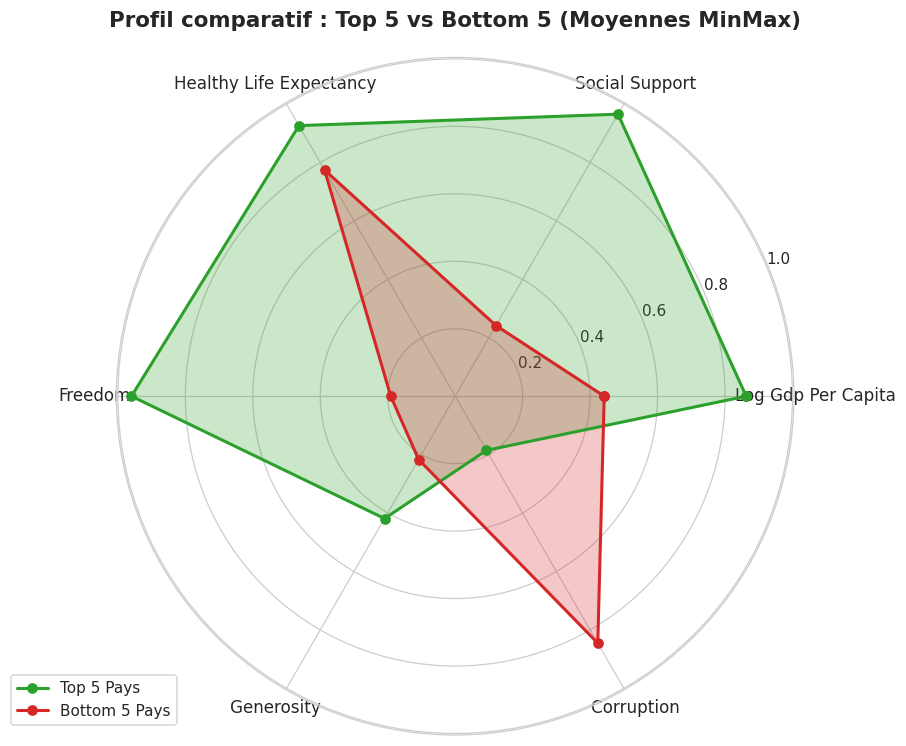

In [54]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Tracé des données
values_top = top5.tolist() + [top5.tolist()[0]]
values_bot = bot5.tolist() + [bot5.tolist()[0]]

ax.plot(angles, values_top, 'o-', linewidth=2, label='Top 5 Pays', color='#2ca02c')
ax.fill(angles, values_top, color='#2ca02c', alpha=0.25)

ax.plot(angles, values_bot, 'o-', linewidth=2, label='Bottom 5 Pays', color='#d62728')
ax.fill(angles, values_bot, color='#d62728', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Profil comparatif : Top 5 vs Bottom 5 (Moyennes MinMax)', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()

## Interprétation :
*  Le Top 5 (en vert) affiche une performance élevée sur l'ensemble des axes, ce qui démontre qu'un niveau de bien-être supérieur repose sur une amélioration synchronisée de tous les piliers.  
*  À l'inverse, le Bottom 5 (en rouge) présente des faiblesses critiques, notamment en matière de PIB, de soutien social et de liberté, ce qui illustre un cercle vicieux de privation.  
*  L'axe Corruption constitue la rupture la plus frappante : la valeur est très élevée pour le Bottom 5 et très faible pour le Top 5, confirmant que l'intégrité institutionnelle est un levier de différenciation majeur.  
## Conclusion :
La transition vers un haut niveau de bien-être ne peut être isolée ou sectorielle. Les données confirment que le bonheur national résulte d'une synergie globale entre prospérité économique, protection sociale et intégrité des institutions publiques.

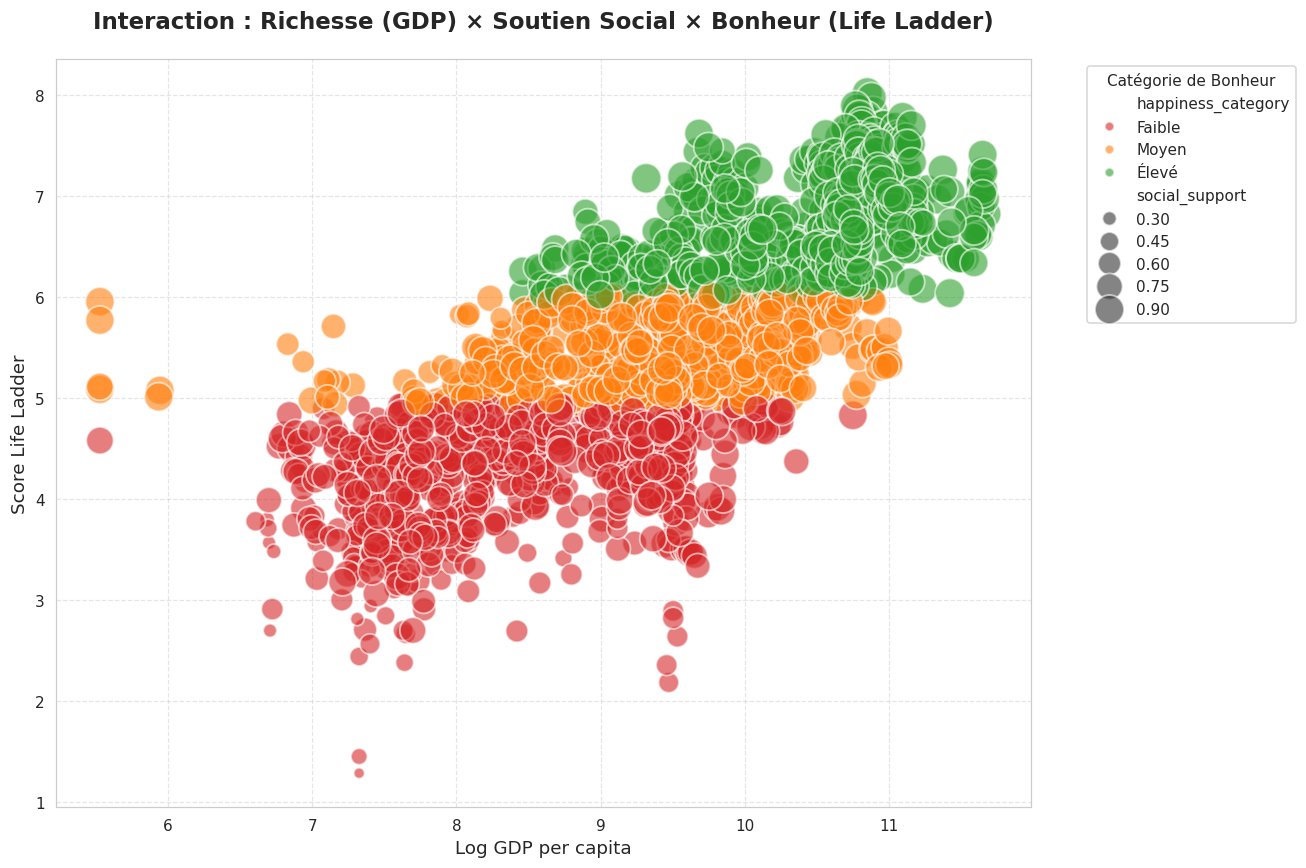

In [55]:
plt.figure(figsize=(12, 8))

# Scatter Bubble : GDP x Life Ladder, avec la taille déterminée par Social Support
# Coloration par 'happiness_category' pour une lisibilité accrue
sns.scatterplot(data=df,
                x='log_gdp_per_capita',
                y='life_ladder',
                size='social_support',
                hue='happiness_category',
                palette={'Faible': '#d62728', 'Moyen': '#ff7f0e', 'Élevé': '#2ca02c'},
                sizes=(50, 400),
                alpha=0.6)

plt.title('Interaction : Richesse (GDP) × Soutien Social × Bonheur (Life Ladder)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Log GDP per capita', fontsize=12)
plt.ylabel('Score Life Ladder', fontsize=12)
plt.legend(title='Catégorie de Bonheur', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interprétation :
*  Les pays les plus heureux (catégorie Élevé, en vert) se situent systématiquement dans la zone haute du graphique, caractérisée par un PIB élevé et une taille de bulle importante, indiquant un soutien social fort.  
*  Le rôle du soutien social : La taille des bulles démontre que le soutien social agit comme un multiplicateur : pour un niveau de PIB similaire, les pays bénéficiant d'un soutien social plus intense atteignent des scores de bonheur supérieurs, agissant ainsi comme un facteur de résilience majeur.  
*  Zones de transition : Les bulles de taille intermédiaire dans la catégorie Moyen révèlent des pays en développement où le soutien social commence à devenir un levier de bien-être essentiel, malgré un PIB encore modéré.  
## Conclusion :
Ce graphique confirme que la richesse matérielle (PIB) est une condition nécessaire mais non suffisante au bien-être. Le soutien social agit comme un complément indispensable, permettant de maximiser le bonheur pour un niveau de revenu donné et constituant un levier de résilience clé pour les nations.

In [56]:
# Sélection des variables (incluant l'axe prioritaire corruption, pib, générosité)
features = ['corruption_zscore', 'log_gdp_per_capita_zscore', 'generosity_zscore',
            'social_support_zscore', 'healthy_life_expectancy_zscore', 'freedom_zscore']

In [57]:
# Définition de la cible et des prédicteurs
X = df[features]
X = sm.add_constant(X) # Ajout de l'ordonnée à l'origine
y = df['life_ladder']

In [58]:
# Modèle OLS (Ordinary Least Squares)
model = sm.OLS(y, X).fit()

In [59]:
# Affichage des résultats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            life_ladder   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     1142.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:36:48   Log-Likelihood:                -2021.5
No. Observations:                2363   AIC:                             4057.
Df Residuals:                    2356   BIC:                             4097.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## Interprétation :
*  Le log_gdp_per_capita_zscore (coef: 0.384) et le social_support_zscore (coef: 0.339) sont les deux leviers les plus puissants du bonheur, leur poids étant nettement supérieur aux autres variables.  
*  Poids de la corruption : Le coefficient de corruption_zscore est de -0.111. Sa $p$-value ($0.000$) confirme que son impact négatif est statistiquement significatif, même en contrôlant l'effet du PIB et des autres facteurs structurels.  
*  Paradoxe Richesse–Générosité : Le coefficient positif de generosity_zscore (0.092) est statistiquement significatif mais demeure relativement faible. Cela confirme que si la générosité contribue positivement au bonheur, elle reste un facteur secondaire par rapport aux fondations économiques et sociales.
## Conclusion :
La régression confirme que le bonheur n'est pas qu'une question de richesse. L'impact de la corruption est bien réel et indépendant : elle pénalise le score de vie au-delà des conséquences économiques de la pauvreté. La structure du bien-être est hiérarchisée : Le modèle démontre que la prospérité économique et le soutien social forment le noyau dur du bonheur, suivis par l'espérance de vie, la liberté et, enfin, la générosité.

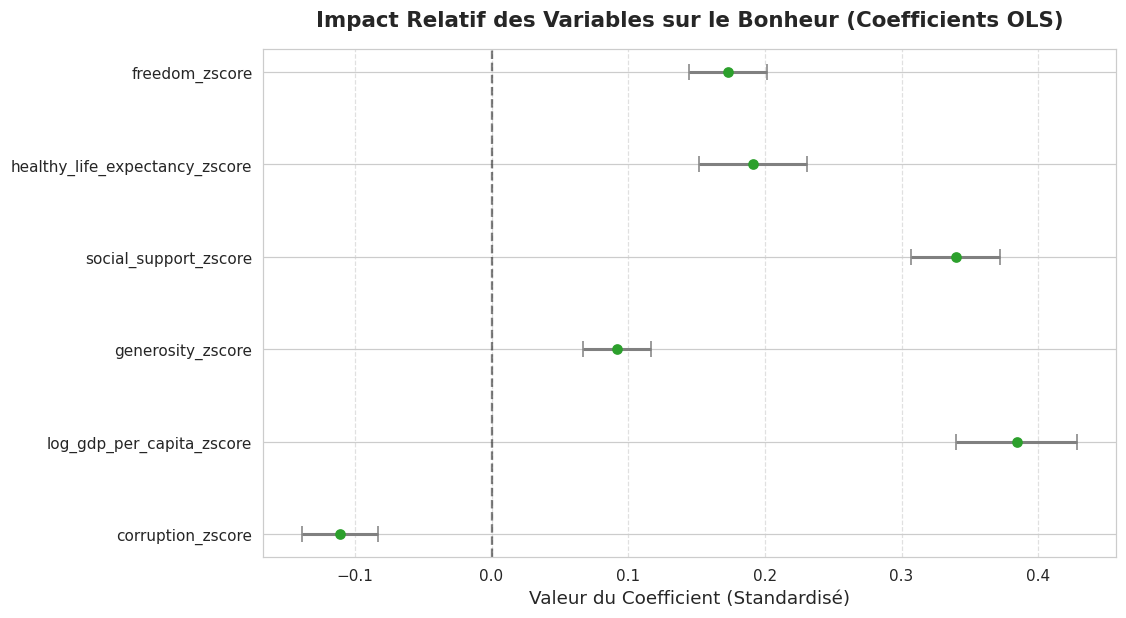

In [60]:
# Extraction des données du modèle pour la visualisation
params = model.params.drop('const')
errors = model.conf_int().drop('const')
errors[0] = params - errors[0] # Calcul de la marge d'erreur
errors[1] = errors[1] - params

# Création du graphe
plt.figure(figsize=(10, 6))
plt.errorbar(params, params.index, xerr=errors.T.values, fmt='o', color='#2ca02c',
             ecolor='gray', elinewidth=2, capsize=5)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.title('Impact Relatif des Variables sur le Bonheur (Coefficients OLS)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Valeur du Coefficient (Standardisé)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [61]:
# ANOVA
# Préparation des groupes
groups = [group['life_ladder'] for _, group in df.groupby('happiness_category')]

In [62]:
# Exécution de l'ANOVA (One-way)
f_val, p_val = stats.f_oneway(*groups)

print(f"Résultat ANOVA : F={f_val:.2f}, p-value={p_val:.4e}")

Résultat ANOVA : F=5876.21, p-value=0.0000e+00


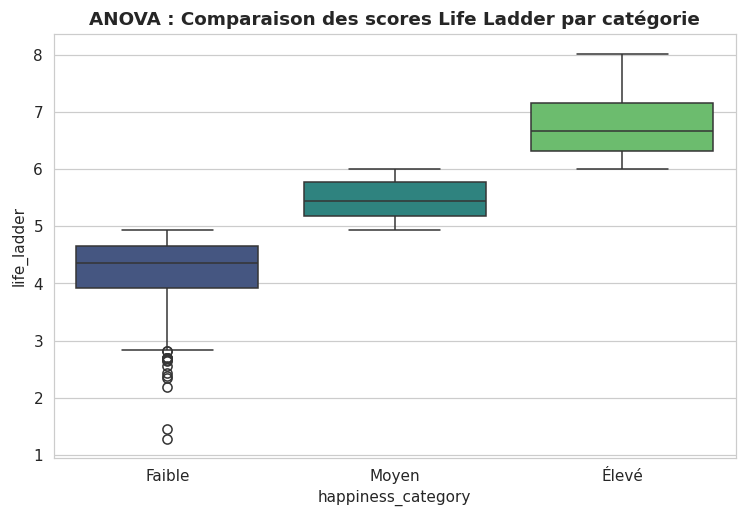

In [63]:
# Visualisation
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='happiness_category', y='life_ladder', palette='viridis')
plt.title('ANOVA : Comparaison des scores Life Ladder par catégorie', fontsize=12, fontweight='bold')
plt.show()

## Interprétation :
 Profils de dispersion :
  * La catégorie Faible présente des valeurs aberrantes (outliers) significatives, soulignant la présence de pays avec des scores de vie exceptionnellement bas.  
  * La catégorie Élevé affiche la plus grande amplitude de scores, témoignant d'une diversité au sein des pays les plus performants.  
  * La catégorie Moyen est la plus resserrée, montrant une certaine homogénéité des scores pour ce groupe.

In [64]:
# Effet COVID (life_ladder_yoy avant/après 2020)
df['covid_period'] = np.where(df['year'] < 2020, 'Avant 2020', 'Après 2020')

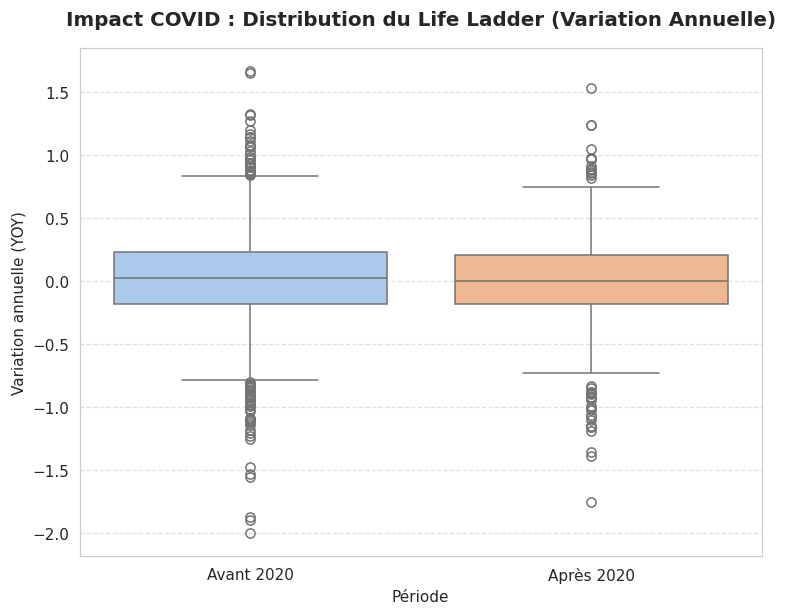

In [65]:
# Visualisation de la distribution
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='covid_period', y='life_ladder_yoy', palette='pastel')

plt.title('Impact COVID : Distribution du Life Ladder (Variation Annuelle)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Période')
plt.ylabel('Variation annuelle (YOY)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [66]:
# Test statistique
avant = df[df['year'] < 2020]['life_ladder_yoy'].dropna()
apres = df[df['year'] >= 2020]['life_ladder_yoy'].dropna()
t_stat, p_val = stats.ttest_ind(avant, apres)
print(f"Test T (Avant vs Après) : p-value = {p_val:.4f}")

Test T (Avant vs Après) : p-value = 0.4513


## Interprétation :
*  Le test T donne une p-value de 0.4513, ce qui est nettement supérieur au seuil classique de 0.05.  
*  Stabilité des variations : Cette valeur indique qu'il n'y a pas de différence statistiquement significative entre les variations annuelles du Life Ladder avant et après 2020.  
*  Lecture du Boxplot : Les deux boîtes à moustaches sont quasi identiques, confirmant que la dynamique de fluctuation du bonheur mondial est restée globalement stable malgré le choc de la pandémie.  
## Conclusion :
Contrairement à l'intuition initiale, le score de bonheur mondial n'a pas subi de déviation structurelle majeure dans sa tendance annuelle à la suite de la crise sanitaire. Cette résilience globale suggère que les facteurs structurels (PIB, soutien social, institutions) ont conservé leur rôle prépondérant dans la détermination du bien-être, sans que l'effet COVID ne vienne durablement altérer la distribution mondiale des scores de vie.

# Synthèse

## Introduction

Ce projet a analysé les déterminants du bien-être (*Life Ladder*) à travers une approche multidimensionnelle. La méthodologie repose sur deux piliers statistiques :

* **Segmentation** : Classification des pays en trois catégories de bonheur, validée par une **ANOVA** ($p < 0.05$).


* **Modélisation** : Utilisation d'une **régression multiple standardisée** (z-score), expliquant **74,4 %** de la variance du bonheur.



## Les Piliers du Bien-être

L'analyse quantitative met en évidence une hiérarchie claire des facteurs influençant le bien-être :

* **Moteurs structurels** : Le PIB par habitant, le soutien social et l'espérance de vie en bonne santé constituent les prédicteurs les plus puissants.


* **Impact éthique et institutionnel** : La corruption exerce un impact négatif significatif et indépendant, agissant comme une « taxe » sur la confiance publique.


* **Le paradoxe de la générosité** : La faible corrélation entre richesse nationale et générosité individuelle confirme que cette dernière relève davantage de dynamiques culturelles que d'indicateurs économiques.


## Résilience et Chocs Exogènes

L'analyse de l'impact de la crise sanitaire (2020) via la variation annuelle du *Life Ladder* montre une résilience mondiale marquée :

* Le test T comparant les périodes avant et après 2020 affiche une **p-value de 0.4513**.


* Ce résultat démontre l'absence de rupture structurelle significative dans la dynamique globale du bonheur.


## Conclusion

Le bien-être des nations n'est pas un phénomène unidimensionnel. Si la prospérité économique (PIB) fonde le socle matériel, le bonheur durable repose sur un équilibre subtil entre :

1. La solidité du **tissu social** (soutien social).


2. L'**intégrité institutionnelle** (absence de corruption).